In [1]:
from google.colab import files
uploaded = files.upload()

Saving SupplyChainGHGEmissionFactors_v1.2_NAICS_CO2e_USD2021.csv to SupplyChainGHGEmissionFactors_v1.2_NAICS_CO2e_USD2021.csv


Forme du dataset : (1016, 8)

--- Informations générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 8 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   2017 NAICS Code                                1016 non-null   int64  
 1   2017 NAICS Title                               1016 non-null   object 
 2   GHG                                            1016 non-null   object 
 3   Unit                                           1016 non-null   object 
 4   Supply Chain Emission Factors without Margins  1016 non-null   float64
 5   Margins of Supply Chain Emission Factors       1016 non-null   float64
 6   Supply Chain Emission Factors with Margins     1016 non-null   float64
 7   Reference USEEIO Code                          1016 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 63.6+ KB

--- Stati

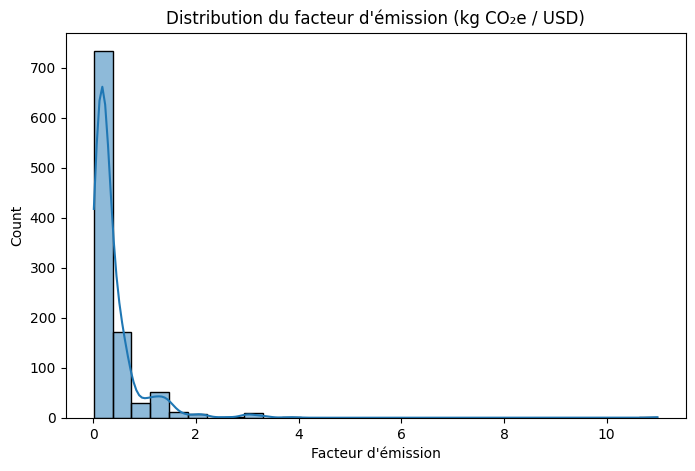

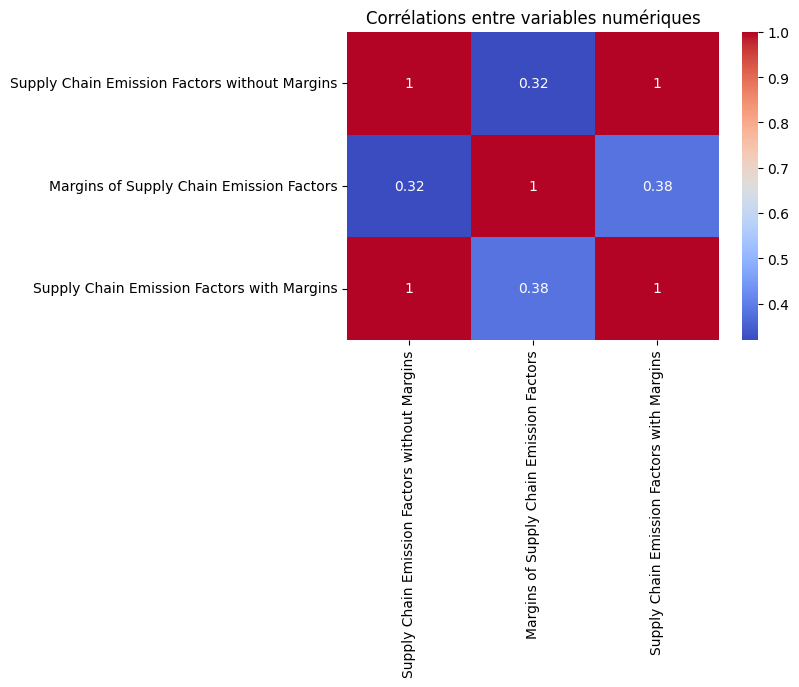

Features numériques : ['2017 NAICS Code', 'Supply Chain Emission Factors without Margins', 'Margins of Supply Chain Emission Factors']
Features catégorielles : ['2017 NAICS Title', 'GHG', 'Reference USEEIO Code']

Linear Regression:
  MAE  = 0.001
  RMSE = 0.004
  R²   = 1.000

Random Forest:
  MAE  = 0.042
  RMSE = 0.534
  R²   = 0.608

XGBoost:
  MAE  = 0.041
  RMSE = 0.524
  R²   = 0.622

--- Comparaison des performances ---
                        MAE      RMSE        R²
Linear Regression  0.000800  0.004065  0.999977
Random Forest      0.042282  0.534438  0.607522
XGBoost            0.040765  0.524454  0.622049


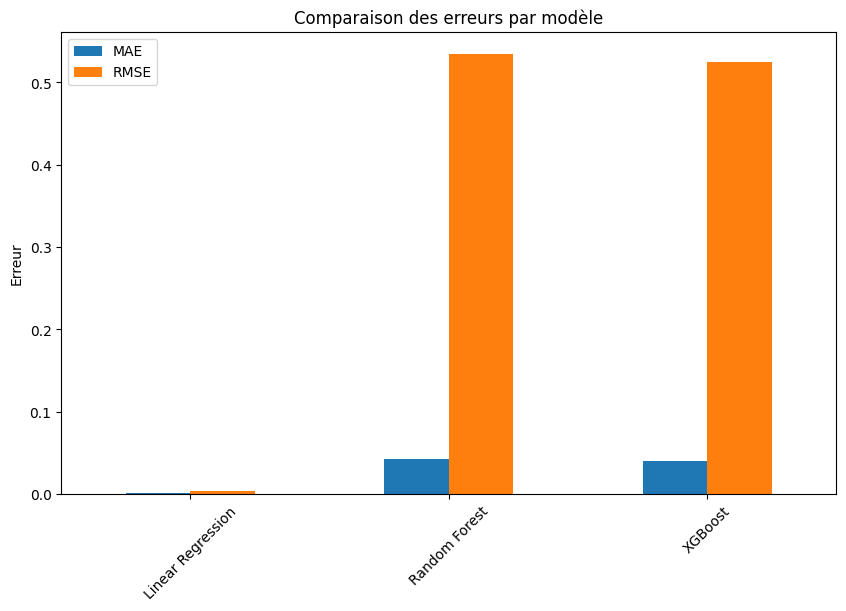

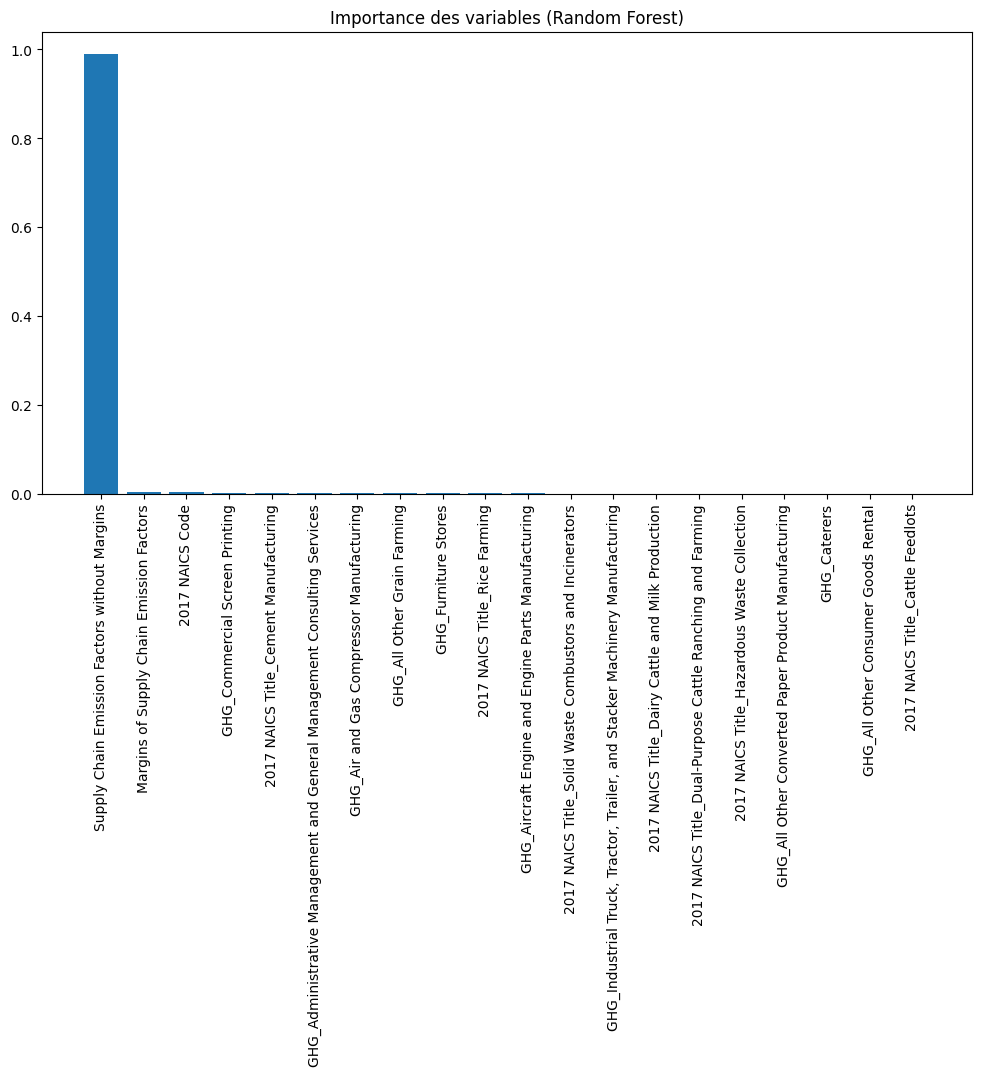

Nombre de secteurs de transport : 50

--- Simulation d'optimisation logistique ---
Réduction appliquée aux secteurs de transport : 15%
Réduction totale des émissions sur ces secteurs : 15.00%


In [2]:
# -*- coding: utf-8 -*-
"""Projet_IA_40_Logistique_Verte.ipynb

Automatically generated by Colab.
"""

# ============================================
# 1. Installation et import des bibliothèques
# ============================================
!pip install xgboost lightgbm --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 2. Chargement des données
# ============================================
# Assure-toi que le fichier est bien uploadé dans l'environnement
df = pd.read_csv('SupplyChainGHGEmissionFactors_v1.2_NAICS_CO2e_USD2021.csv')
print("Forme du dataset :", df.shape)
df.head()

# ============================================
# 3. Analyse exploratoire rapide
# ============================================
print("\n--- Informations générales ---")
df.info()

print("\n--- Statistiques descriptives des colonnes numériques ---")
df.describe()

# Distribution de la cible (facteur d'émission avec marge)
target = 'Supply Chain Emission Factors with Margins'
plt.figure(figsize=(8,5))
sns.histplot(df[target], bins=30, kde=True)
plt.title('Distribution du facteur d\'émission (kg CO₂e / USD)')
plt.xlabel('Facteur d\'émission')
plt.show()

# Matrice de corrélation (entre colonnes numériques)
numeric_cols = ['Supply Chain Emission Factors without Margins', 'Margins of Supply Chain Emission Factors', target]
plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Corrélations entre variables numériques')
plt.show()

# ============================================
# 4. Préparation des données pour le ML
# ============================================
# On garde toutes les colonnes sauf la cible
X = df.drop(columns=[target])
y = df[target]

# Séparation train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identifier les colonnes numériques et catégorielles
# Numériques : celles qui sont de type float/int (on exclut les colonnes non pertinentes comme 'GHG' qui est constante)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Supprimer les colonnes numériques qui sont des identifiants ou constantes
# Ici, on garde tout car 'Margins' est numérique utile, 'Supply Chain Emission Factors without Margins' aussi
# Par contre, 'Unit' est constant (toutes les lignes identiques) -> on peut l'ignorer
if 'Unit' in categorical_features:
    categorical_features.remove('Unit')  # colonne constante, inutile pour le modèle

print("Features numériques :", numeric_features)
print("Features catégorielles :", categorical_features)

# Préprocesseur
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# ============================================
# 5. Modèles et évaluation
# ============================================
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"\n{name}:")
    print(f"  MAE  = {mae:.3f}")
    print(f"  RMSE = {rmse:.3f}")
    print(f"  R²   = {r2:.3f}")

# ============================================
# 6. Comparaison des modèles
# ============================================
results_df = pd.DataFrame(results).T
print("\n--- Comparaison des performances ---")
print(results_df)

results_df[['MAE', 'RMSE']].plot(kind='bar', figsize=(10,6))
plt.title('Comparaison des erreurs par modèle')
plt.ylabel('Erreur')
plt.xticks(rotation=45)
plt.show()

# ============================================
# 7. Importance des variables (pour Random Forest)
# ============================================
# On ré-entraîne un pipeline Random Forest pour extraire les features
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_pipeline.fit(X_train, y_train)

# Récupération des noms de features après transformation
# Pour les numériques, on garde les noms d'origine
feature_names = numeric_features.copy()
# Pour les catégorielles, on récupère les noms one-hot
for cat in categorical_features:
    encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    # On doit adapter pour obtenir les noms après transformation
    # Comme le pipeline est déjà entraîné, on peut obtenir les catégories
    cats = encoder.categories_[0]
    feature_names.extend([f"{cat}_{c}" for c in cats])

importances = rf_pipeline.named_steps['regressor'].feature_importances_
indices = np.argsort(importances)[::-1][:20]  # top 20

plt.figure(figsize=(12,6))
plt.title('Importance des variables (Random Forest)')
plt.bar(range(len(indices)), importances[indices], align='center')
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

# ============================================
# 8. Simulation de réduction des émissions par optimisation logistique
# ============================================
# On va prendre les secteurs de transport (codes NAICS 48xxx) et simuler
# une réduction de 15% de leur facteur d'émission (ex: passage route->rail)
# puis recalculer la réduction globale.

# Sélectionner les lignes correspondant au transport
transport_codes = ['48' + str(i).zfill(4) for i in range(1000, 5000)]  # approx
transport_mask = df['2017 NAICS Code'].astype(str).str.startswith('48')
df_transport = df[transport_mask].copy()
print(f"Nombre de secteurs de transport : {len(df_transport)}")

# Prédire les facteurs actuels avec le meilleur modèle (Random Forest)
best_model = rf_pipeline
y_transport_actual = df_transport[target]  # facteurs réels

# Simuler une réduction de 15% pour ces secteurs
reduction_rate = 0.15  # 15% de réduction
y_transport_reduced = y_transport_actual * (1 - reduction_rate)

# Calculer la réduction totale en tonnes CO₂e par dollar dépensé
# On suppose une dépense totale dans les secteurs transport = 1 million USD (exemple)
spend_per_sector = 1e6 / len(df_transport)  # répartition égale
total_emissions_actual = (y_transport_actual * spend_per_sector).sum()
total_emissions_reduced = (y_transport_reduced * spend_per_sector).sum()
reduction_pct = (total_emissions_actual - total_emissions_reduced) / total_emissions_actual * 100

print(f"\n--- Simulation d'optimisation logistique ---")
print(f"Réduction appliquée aux secteurs de transport : {reduction_rate*100:.0f}%")
print(f"Réduction totale des émissions sur ces secteurs : {reduction_pct:.2f}%")

# On peut également prédire la réduction pour un secteur particulier à l'aide du modèle
# en modifiant ses caractéristiques (par exemple, changer son code NAICS pour un mode plus vert).
# Pour rester simple, cette simulation donne déjà une idée concrète.